# Threading

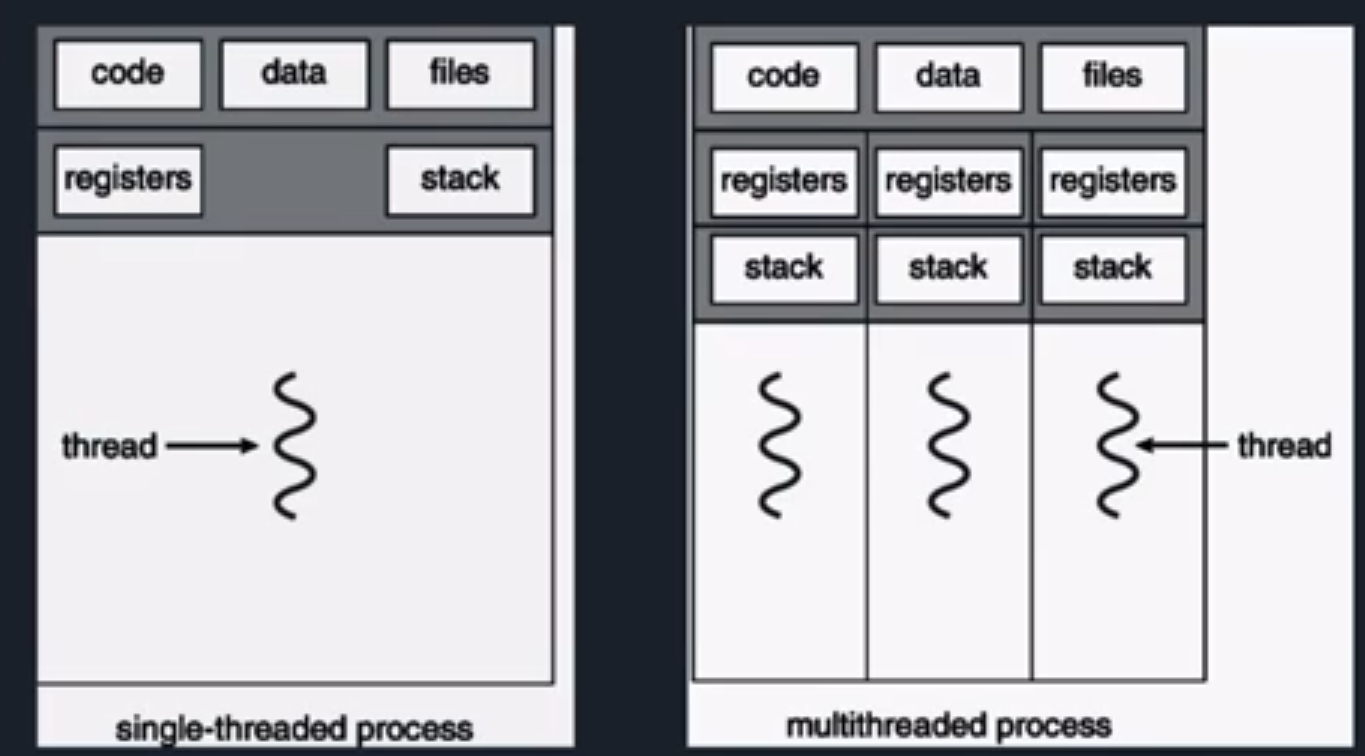

In [1]:
# Thread - A thread is the smallest unit of execution inside a process.

import time

start_time=time.time()
def something():
  print("Going to sleep...")
  time.sleep(1)
  print("Woken up")

something()
something()

end_time=time.time()
print(f"Time taken={end_time-start_time} sec")


Going to sleep...
Woken up
Going to sleep...
Woken up
Time taken=2.0017037391662598 sec


In [8]:
import time
import threading

start_time=time.time()
def something(id):
  print(f"Going to sleep...{id}")
  time.sleep(1)
  print(f"Woken up.. {id}")


t1=threading.Thread(target=something,args=[0])
t2=threading.Thread(target=something,args=[1])
t1.start()
t2.start()
t1.join()
t2.join()


end_time=time.time()
print(f"Time taken={end_time-start_time} sec")

Going to sleep...0
Going to sleep...1
Woken up.. 0
Woken up.. 1
Time taken=1.004533290863037 sec


In [9]:
import time
import threading

start_time=time.time()
def something(id):
  print(f"Going to sleep...{id}")
  time.sleep(1)
  print(f"Woken up.. {id}")

threads=[threading.Thread(target=something,args=[i])for i in range(10)]

for thread in threads:
  thread.start()

for thread in threads:
  thread.join()


end_time=time.time()
print(f"Time taken={end_time-start_time} sec")

Going to sleep...0
Going to sleep...1
Going to sleep...2
Going to sleep...3
Going to sleep...4
Going to sleep...5
Going to sleep...6
Going to sleep...7
Going to sleep...8
Going to sleep...9
Woken up.. 0
Woken up.. 2
Woken up.. 1
Woken up.. 3
Woken up.. 4
Woken up.. 5
Woken up.. 6
Woken up.. 7
Woken up.. 8
Woken up.. 9
Time taken=1.0067493915557861 sec


In [17]:
import threading

bal=200

lock=threading.Lock()
def deposit(amt,times,lock):
  global bal

  for i in range(times):
    lock.acquire()
    bal+=amt
    lock.release()

def withdraw(amt,times,lock):
  global bal

  for i in range(times):
    lock.acquire()
    bal-=amt
    lock.release()


dep_thread=threading.Thread(target=deposit,args=[1,10000,lock])
with_thread=threading.Thread(target=withdraw,args=[1,10000,lock])

dep_thread.start()
with_thread.start()

dep_thread.join()
with_thread.join()
print(bal)

200
